In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

In [2]:
# 1. Load the dataset
data = pd.read_csv('retail_store_inventory.csv')

# 2. Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# 3. Feature Engineering (Extract time-based features)
data['Day of Week'] = data['Date'].dt.dayofweek  # Monday=0, Sunday=6
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

# 4. Define features (X) and target (y)
X = data.drop(columns=['Date', 'Product ID', 'Store ID', 'Units Sold', 'Demand Forecast'])
y = data['Units Sold']  # Target variable: Units Sold

# 5. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Handling categorical features (One-Hot Encoding) for categorical variables
numeric_features = ['Price', 'Discount', 'Inventory Level', 'Units Ordered', 'Competitor Pricing', 'Day of Week', 'Month', 'Year']
categorical_features = ['Category', 'Region', 'Weather Condition', 'Holiday/Promotion', 'Seasonality']

# Numeric transformer (No imputation needed)
numeric_transformer = Pipeline(steps=[
    ('scaler', None)  # No scaling or transformation for the numeric features
])

# Categorical transformer with one hot encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encoding of categorical variables
])

# Column transformer combining both transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 7. Model Pipeline: GradientBoosting Regressor
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])


In [3]:
# 8. Train the model
model.fit(X_train, y_train)

# 9. Predict on the test set
y_pred = model.predict(X_test)

Mean Absolute Error (MAE): 69.02
Root Mean Squared Error (RMSE): 88.21
R-squared: 0.3428


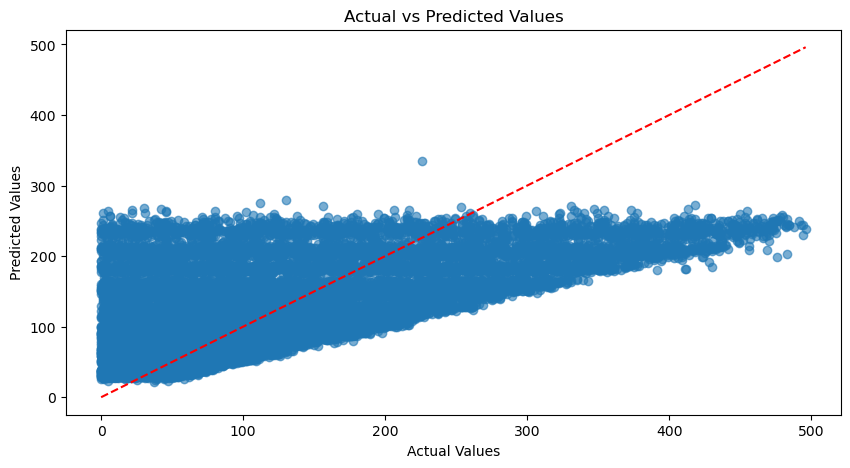

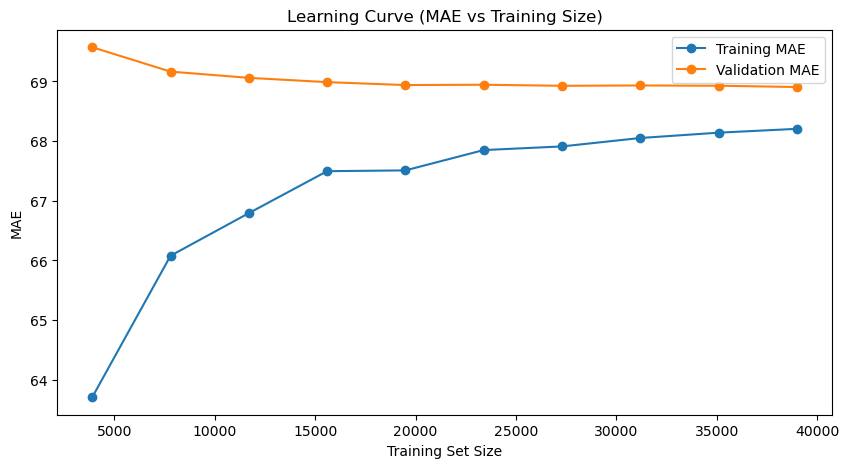

In [4]:
# 10. Calculate evaluation metrics: MAE, RMSE, R-squared
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared: {r2:.4f}")

# 11. Plot Actual vs Predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

# 12. Plot learning curve (for illustration)
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 10), cv=3, n_jobs=-1)

train_errors = -np.mean(train_scores, axis=1)
test_errors = -np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_errors, 'o-', label="Training MAE")
plt.plot(train_sizes, test_errors, 'o-', label="Validation MAE")
plt.xlabel('Training Set Size')
plt.ylabel('MAE')
plt.title('Learning Curve (MAE vs Training Size)')
plt.legend()
plt.show()